- Dados: Focos de calor do INPE na frequência anual - https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/anual/EstadosBr_sat_ref/MG/

- Dados: Focos de calor do INPE na frequência mensal - https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/mensal/Brasil/

- Código realizado por: Enrique V. Mattos - 07/04/2024

# **1° Passo:** Preparando ambiente

In [1]:
# instalando bibliotecas
!pip install -q ultraplot cartopy salem rasterio

# importa bibliotecas
import numpy as np
import ultraplot as uplt
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import time
from zipfile import ZipFile
import salem
from datetime import datetime
import glob
import xarray as xr
import os
import cartopy.crs as ccrs
import warnings
warnings.filterwarnings('ignore')

# monta drive
from google.colab import drive
drive.mount('/content/drive')

# caminho do drive
dir = '/content/drive/MyDrive/5_EXTENSAO/02_prefeitura_analise_periodo_chuvoso_2024_2025'

# leitura do shapefile do Brasil
shapefile_brasil = salem.read_shapefile('https://github.com/evmpython/shapefile/raw/main/brasil/BRAZIL.shp')

# url dos shapefiles
url = 'https://github.com/evmpython/shapefile/raw/main/'

# leitura do shapefile com a biblioteca SALEM
shp = salem.read_shapefile(f'{url}itajuba/itajuba.shp')

# limites do Brasil
lonmin, lonmax, latmin, latmax = -75.0, -33.0, -35.0, 7.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.0 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/ultraplot/__init__.py:77: UltraPlotWarning: Rebuilding font cache. This usually happens after installing or updating ultraplot.
  register_fonts(default=True)


Mounted at /content/drive


# **PARTE 1):** Leitura dos dados de focos de calor

##Baixando os dados

In [2]:
#==============================================================#
#                         2003 à 2024
#==============================================================#
# Exemplo: focos_br_mg_ref_2024.zip

# ano inicial e final - SÃO OS ANOS COMPLETOS
anoi, anof = 2003, datetime.now().year - 1

# loop dos anos
for ano in np.arange(anoi, anof+1):

    # baixando arquivos
    filename = f'https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/anual/EstadosBr_sat_ref/MG/focos_br_mg_ref_{ano}.zip'
    !wget {filename}

    # descompactando arquivo ZIP
    with ZipFile(f"/content/focos_br_mg_ref_{ano}.zip", 'r') as zObject:

        # extraindo os membros do arquivo ZIP para uma localicação específica
        zObject.extractall(path='/content')

#==============================================================#
#                         2025
#==============================================================#
# Exemplo: focos_mensal_br_202501.csv

# ano atual - ANO QUE ESTA EM ANDAMENTO
ano_atual = anof + 1
mes_atual = datetime.now().month

# ftp dos dados mensais
url = f'https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/mensal/Brasil/'

# loop dos meses
ano_mesi, ano_mesf = f'{str(ano_atual)}0101', f'{str(ano_atual)}{str(mes_atual+1).zfill(2)}01'
for data in pd.date_range(ano_mesi, ano_mesf, freq='1M'):

    # estrai ano e mês
    ano = data.strftime('%Y')
    mes = data.strftime('%m')

    # baixa o arquivo
    filename = f'{url}focos_mensal_br_{ano}{mes}.csv'
    !wget {filename}

--2025-04-13 23:52:58--  https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/anual/EstadosBr_sat_ref/MG/focos_br_mg_ref_2003.zip
Resolving dataserver-coids.inpe.br (dataserver-coids.inpe.br)... 150.163.218.16
Connecting to dataserver-coids.inpe.br (dataserver-coids.inpe.br)|150.163.218.16|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 382636 (374K) [application/zip]
Saving to: ‘focos_br_mg_ref_2003.zip’

focos_br_mg_ref_200 100%[===================>] 373.67K   624KB/s    in 0.6s    

2025-04-13 23:53:00 (624 KB/s) - ‘focos_br_mg_ref_2003.zip’ saved [382636/382636]

--2025-04-13 23:53:00--  https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/anual/EstadosBr_sat_ref/MG/focos_br_mg_ref_2004.zip
Resolving dataserver-coids.inpe.br (dataserver-coids.inpe.br)... 150.163.218.16
Connecting to dataserver-coids.inpe.br (dataserver-coids.inpe.br)|150.163.218.16|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 265077 (259K) [

In [3]:
ano_atual, mes_atual,

(2025, 4)

In [4]:
datetime.now()

datetime.datetime(2025, 4, 13, 23, 53, 35, 256201)

##Lendo os dados de 2003-2024
- São os dados por `ANO` do `Brasil` do satélite de referência `AQUA`.

In [5]:
# cria uma tabela (conhecida também com o nome em inglês de "dataframe") vazia
df_2003_a_2024 = pd.DataFrame()

# loop de cada arquivo da lista files
for ano in np.arange(anoi, anof+1):

    # leitura da tabela
    df0 = pd.read_csv(f'/content/focos_br_mg_ref_{ano}.csv')

    # junta a tabela que foi lida com a anterior
    df_2003_a_2024 = pd.concat([df_2003_a_2024, df0], ignore_index=True)

# remove colunas
df_2003_a_2024.drop(['id_bdq','foco_id','pais'], axis=1, inplace=True)

# renomeia coluna
df_2003_a_2024.rename(columns={'data_pas': 'data'}, inplace=True)

# reposiciona as colunas
df_2003_a_2024 = df_2003_a_2024[['data','lat','lon','municipio','estado','bioma']]

# mostra o dataframe
df_2003_a_2024

,data,lat,lon,municipio,estado,bioma
0,2003-05-15 17:05:00,-17.61200,-47.16000,GUARDA-MOR,MINAS GERAIS,Cerrado
1,2003-05-15 17:05:00,-17.01500,-46.32900,PARACATU,MINAS GERAIS,Cerrado
2,2003-05-15 17:05:00,-17.61400,-47.17200,GUARDA-MOR,MINAS GERAIS,Cerrado
3,2003-05-15 17:04:00,-19.98700,-48.25100,CONCEIÇÃO DAS ALAGOAS,MINAS GERAIS,Cerrado
4,2003-05-15 17:04:00,-19.98800,-48.26100,CONCEIÇÃO DAS ALAGOAS,MINAS GERAIS,Cerrado
...,...,...,...,...,...,...
232789,2024-12-29 18:06:00,-19.16358,-50.54485,SANTA VITÓRIA,MINAS GERAIS,Mata Atlântica
232790,2024-12-30 17:09:00,-20.89467,-45.28021,CAMPO BELO,MINAS GERAIS,Mata Atlântica
232791,2024-12-31 17:47:00,-20.57788,-45.90155,PIMENTA,MINAS GERAIS,Cerrado
232792,2024-12-31 17:49:00,-20.23230,-49.24949,FRONTEIRA,MINAS GERAIS,Cerrado


##Lendo os dados de 2025
- São os dados por `MÊS` do `Brasil` de `TODOS` satélites.

In [6]:
# cria uma tabela
df_2025 = pd.DataFrame()

# lista os arquivos mensais do ano atual
files = sorted(glob.glob('/content/focos_mensal_br_*csv'))

# loop de cada arquivo da lista files
for file in files:

    # leitura da tabela
    df0 = pd.read_csv(file, usecols=['lat', 'lon', 'data_hora_gmt', 'satelite', 'municipio', 'estado', 'bioma'])

    # junta a tabela que foi lida com a anterior
    df_2025 = pd.concat([df_2025, df0], ignore_index=True)

# seleciona apenas para MG e para o satélite de referência AQUA_M-T
df_2025 = df_2025[ (df_2025['estado']=='MINAS GERAIS') & (df_2025['satelite']=='AQUA_M-T') ]

# remove colunas
df_2025.drop(['satelite'], axis=1, inplace=True)

# renomeia coluna
df_2025.rename(columns={'data_hora_gmt': 'data'}, inplace=True)

# reposiciona as colunas
df_2025 = df_2025[['data','lat','lon','municipio','estado','bioma']]

# mostra tabela
df_2025

,data,lat,lon,municipio,estado,bioma
4684,2025-01-02 17:28:00,-21.23029,-43.81480,BARBACENA,MINAS GERAIS,Mata Atlântica
14439,2025-01-05 17:49:00,-18.69869,-49.56908,CAPINÓPOLIS,MINAS GERAIS,Cerrado
14453,2025-01-05 17:49:00,-19.28485,-49.54511,ITUIUTABA,MINAS GERAIS,Cerrado
14455,2025-01-05 17:49:00,-18.89811,-49.27734,CANÁPOLIS,MINAS GERAIS,Mata Atlântica
14456,2025-01-05 17:49:00,-19.89313,-48.75694,PIRAJUBA,MINAS GERAIS,Cerrado
...,...,...,...,...,...,...
164297,2025-04-10 17:49:00,-18.73800,-50.08005,SANTA VITÓRIA,MINAS GERAIS,Cerrado
164300,2025-04-10 17:49:00,-20.56118,-45.19861,ITAPECERICA,MINAS GERAIS,Mata Atlântica
164301,2025-04-10 17:49:00,-20.04857,-45.41642,LAGOA DA PRATA,MINAS GERAIS,Cerrado
164302,2025-04-10 17:49:00,-19.35309,-44.83947,POMPÉU,MINAS GERAIS,Cerrado


##Junta os dados de 2003-2024 com 2025

In [7]:
# junta os dataframes
df_total = pd.concat([df_2003_a_2024, df_2025], ignore_index=True)

# transforma a coluna "datahora" para o formato "datetime"
df_total['data'] = pd.to_datetime(df_total['data'])

# seta a coluna "datahora" como o índice da tabela
df_total.set_index('data', inplace=True)

# mostra o dataframe final
df_total

,lat,lon,municipio,estado,bioma
data,,,,,
2003-05-15 17:05:00,-17.61200,-47.16000,GUARDA-MOR,MINAS GERAIS,Cerrado
2003-05-15 17:05:00,-17.01500,-46.32900,PARACATU,MINAS GERAIS,Cerrado
2003-05-15 17:05:00,-17.61400,-47.17200,GUARDA-MOR,MINAS GERAIS,Cerrado
2003-05-15 17:04:00,-19.98700,-48.25100,CONCEIÇÃO DAS ALAGOAS,MINAS GERAIS,Cerrado
2003-05-15 17:04:00,-19.98800,-48.26100,CONCEIÇÃO DAS ALAGOAS,MINAS GERAIS,Cerrado
...,...,...,...,...,...
2025-04-10 17:49:00,-18.73800,-50.08005,SANTA VITÓRIA,MINAS GERAIS,Cerrado
2025-04-10 17:49:00,-20.56118,-45.19861,ITAPECERICA,MINAS GERAIS,Mata Atlântica
2025-04-10 17:49:00,-20.04857,-45.41642,LAGOA DA PRATA,MINAS GERAIS,Cerrado


# **PARTE 2):** Agrupando os dados por mês

In [8]:
df_total.head(2)

,lat,lon,municipio,estado,bioma
data,,,,,
2003-05-15 17:05:00,-17.612,-47.160,GUARDA-MOR,MINAS GERAIS,Cerrado
2003-05-15 17:05:00,-17.015,-46.329,PARACATU,MINAS GERAIS,Cerrado


In [9]:
%%time
# agrupa os dados por "MÊS"
df_mes = df_total.groupby('estado').get_group('MINAS GERAIS').groupby(pd.Grouper(freq='1M')).count()['estado']

# preenche com zeros os meses de 2024 que ainda não chegaram
ano_mes_dia = []
ano_mesi, ano_mesf = f'{str(anoi)}0101', f'{str(ano_atual)}1231'
for data in pd.date_range(ano_mesi, ano_mesf, freq='1M'):
    ano_mes_dia.append(data.strftime('%Y-%m-%d'))
datas = np.array(ano_mes_dia)
df_mes = df_mes.reindex(datas, fill_value=np.nan)

# mostra os dados
df_mes

CPU times: user 134 ms, sys: 9.43 ms, total: 143 ms
Wall time: 147 ms


,estado
data,
2003-01-31,47.0
2003-02-28,181.0
2003-03-31,123.0
2003-04-30,265.0
2003-05-31,369.0
...,...
2025-08-31,NaN
2025-09-30,NaN
2025-10-31,NaN


In [10]:
# valores
df_mes.values

array([  47.,  181.,  123.,  265.,  369., 1065., 1465., 2094., 7489.,
       5540.,  508.,  280.,   29.,   36.,  125.,  161.,  237.,  303.,
        831., 1865., 5288., 3062., 1066.,  226.,   52.,  106.,  157.,
        227.,  230.,  336.,  874., 1520., 2301., 7145.,  548.,  206.,
        168.,  135.,  103.,  153.,  379.,  444., 1277., 1948., 3077.,
        815.,  195.,  138.,  115.,   99.,  263.,  188.,  473.,  884.,
       1429., 3681., 6800., 5880., 2306.,  396.,   99.,   84.,  113.,
        172.,  285.,  283.,  767., 1448., 2765., 4299., 1436.,  137.,
         82.,  104.,  132.,   61.,  200.,  216.,  515.,  702., 1380.,
       1128.,  310.,  106.,  132.,  185.,  121.,  144.,  246.,  619.,
       1040., 3634., 5200., 2196.,  119.,  130.,  112.,  131.,   82.,
         97.,  201.,  387.,  889., 2445., 5930., 1251.,  192.,   49.,
         90.,  140.,  181.,  201.,  178.,  245.,  701.,  919., 2919.,
       4038.,  258.,  238.,   93.,  161.,  136.,   80.,  182.,  191.,
        512.,  933.,

In [11]:
# matriz com formato de anos x meses
focos_table = np.reshape(df_mes.values, ((ano_atual-anoi)+1, 12), order='C')
focos_table

array([[  47.,  181.,  123.,  265.,  369., 1065., 1465., 2094., 7489.,
        5540.,  508.,  280.],
       [  29.,   36.,  125.,  161.,  237.,  303.,  831., 1865., 5288.,
        3062., 1066.,  226.],
       [  52.,  106.,  157.,  227.,  230.,  336.,  874., 1520., 2301.,
        7145.,  548.,  206.],
       [ 168.,  135.,  103.,  153.,  379.,  444., 1277., 1948., 3077.,
         815.,  195.,  138.],
       [ 115.,   99.,  263.,  188.,  473.,  884., 1429., 3681., 6800.,
        5880., 2306.,  396.],
       [  99.,   84.,  113.,  172.,  285.,  283.,  767., 1448., 2765.,
        4299., 1436.,  137.],
       [  82.,  104.,  132.,   61.,  200.,  216.,  515.,  702., 1380.,
        1128.,  310.,  106.],
       [ 132.,  185.,  121.,  144.,  246.,  619., 1040., 3634., 5200.,
        2196.,  119.,  130.],
       [ 112.,  131.,   82.,   97.,  201.,  387.,  889., 2445., 5930.,
        1251.,  192.,   49.],
       [  90.,  140.,  181.,  201.,  178.,  245.,  701.,  919., 2919.,
        4038.,  258.

# **PARTE 3):** Plota figura

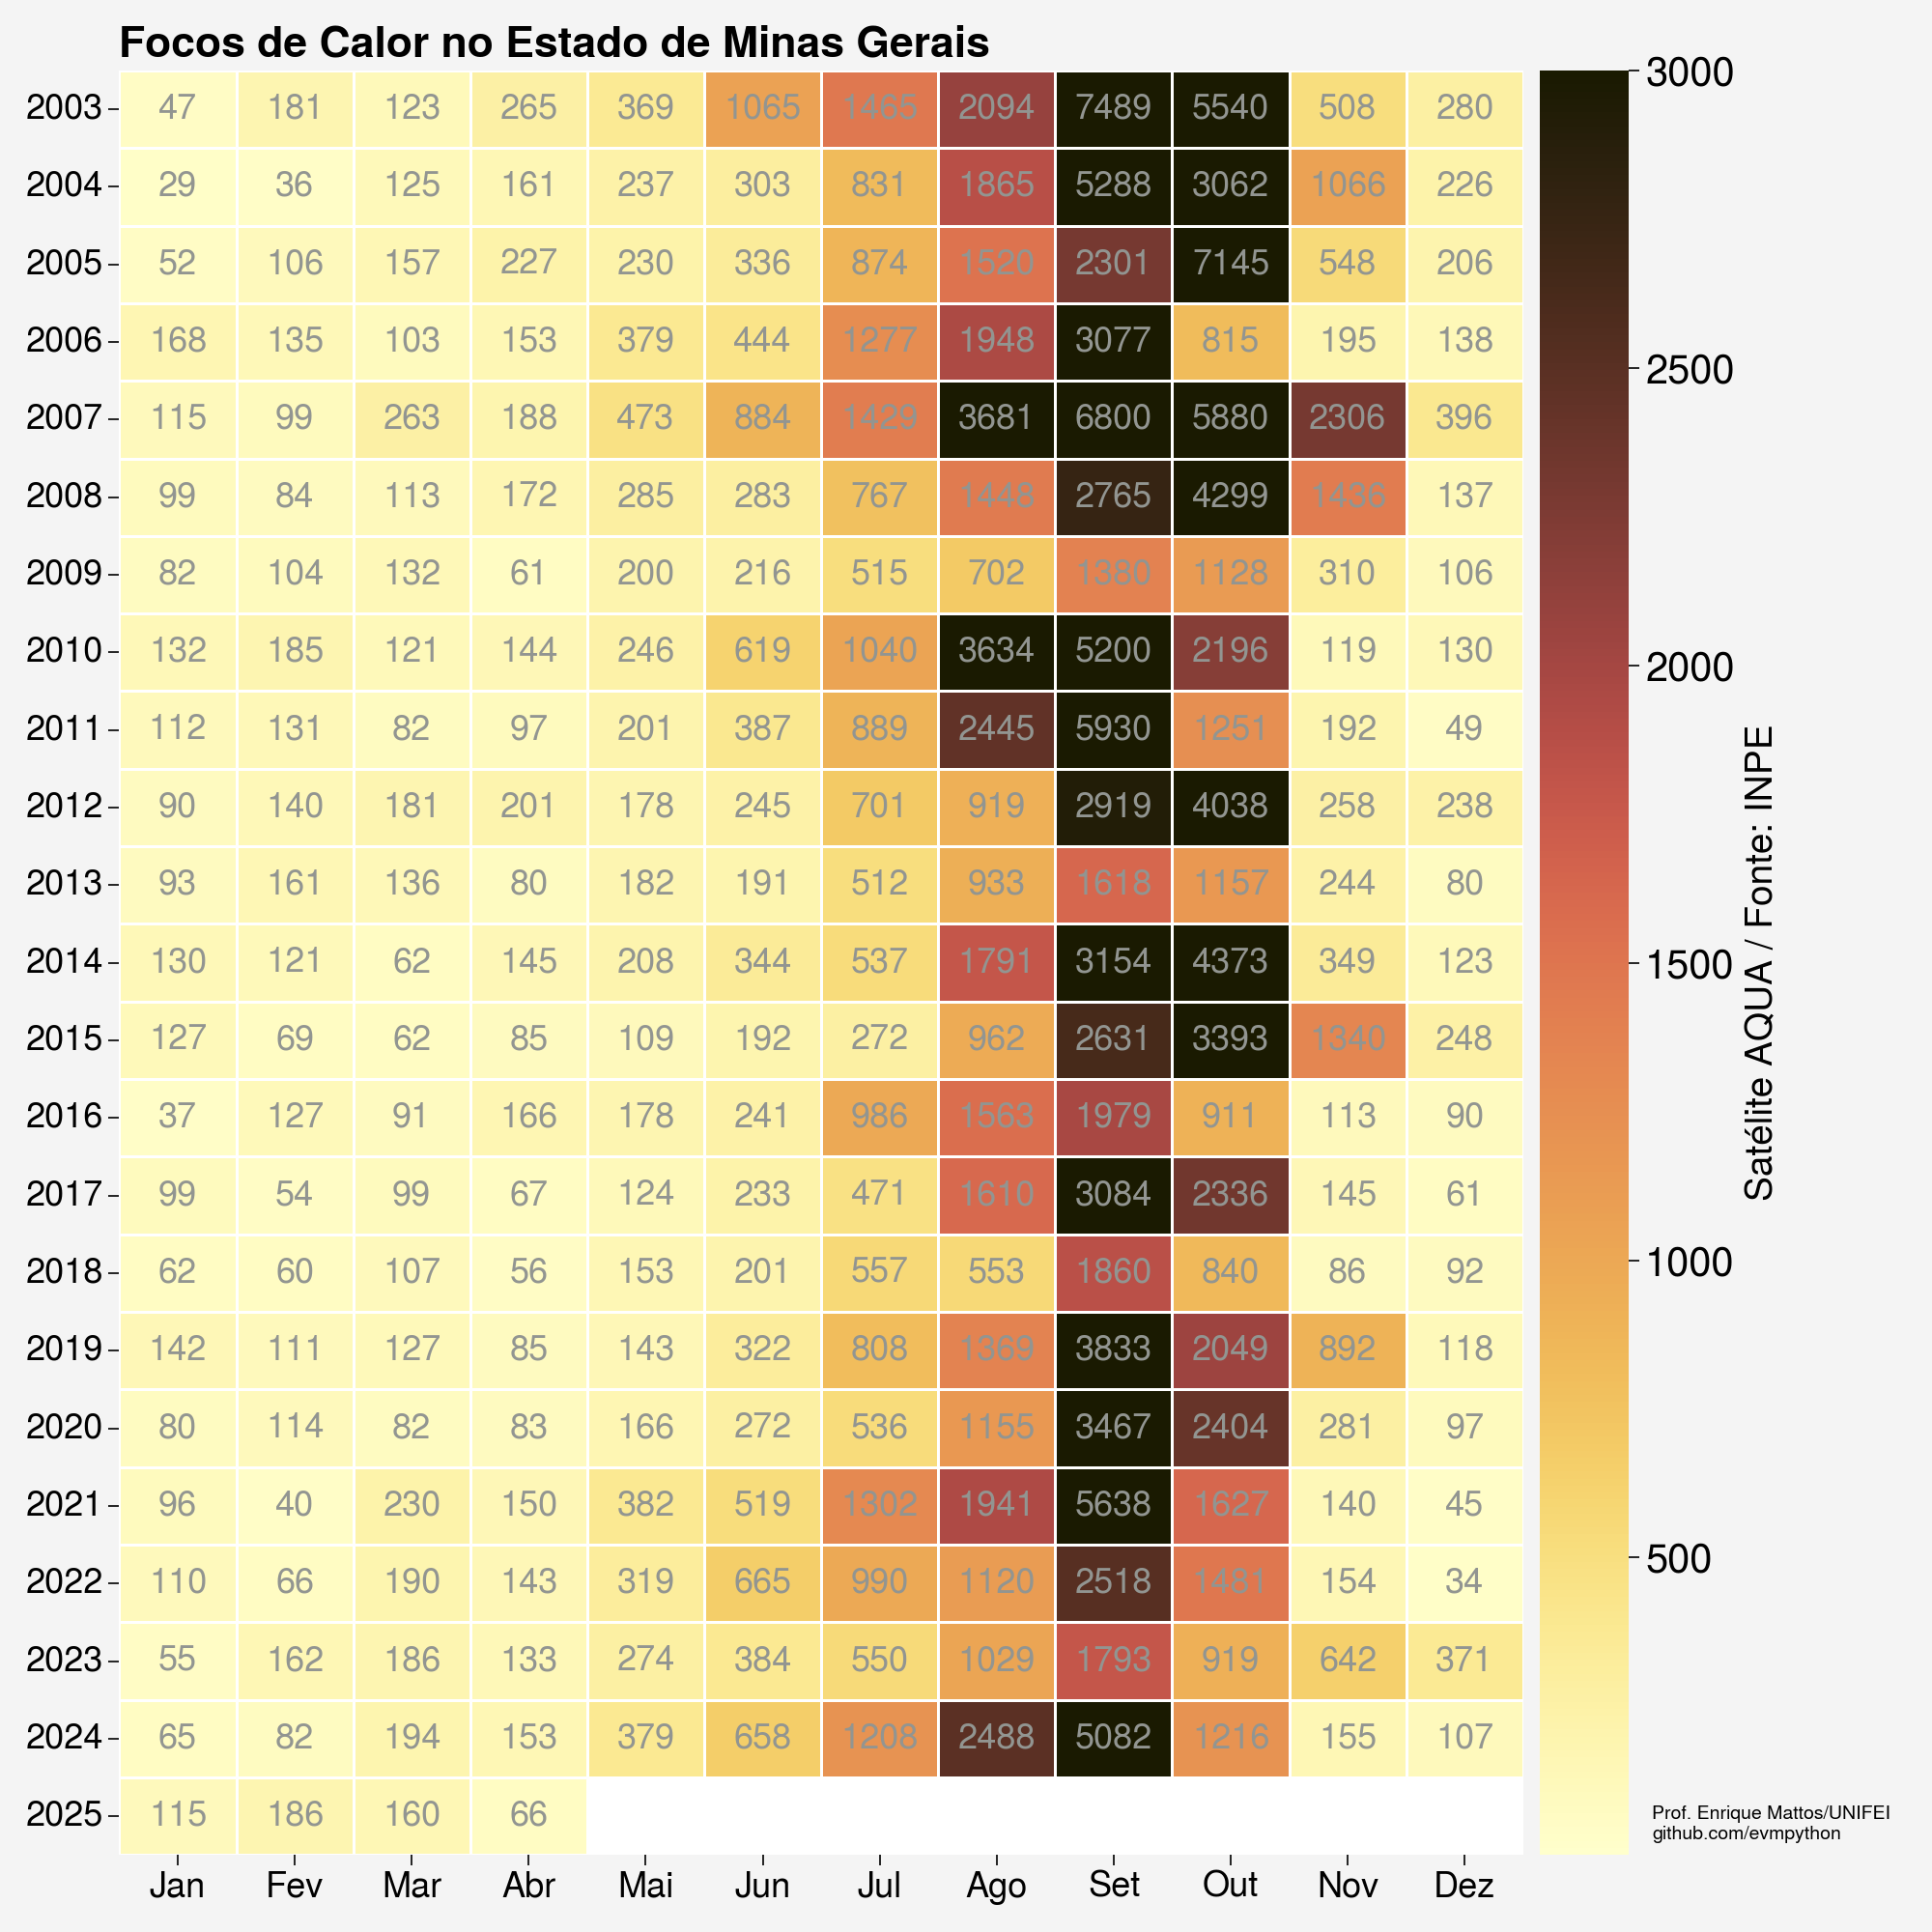

CPU times: user 2.47 s, sys: 141 ms, total: 2.61 s
Wall time: 3.3 s


In [14]:
%%time
#========================================================#
#               DEFINIÇÕES INICIAIS
#========================================================#
# moldura da figura
fig, ax = plt.subplots(figsize=(10,10))

# criando heatmap com seaborn
sns.heatmap(focos_table,
            vmin=0.1, vmax=3000,
            cmap='lajolla',
            xticklabels=['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'],
            yticklabels=uplt.arange(anoi, anof+1, 1),
            linewidth=0.5,
            linecolor='white',
            cbar_kws={'label': ' ',
                      'shrink': 1.0,
                      'pad': 0.01,
                      'orientation': 'vertical'},
            annot=True, fmt=".0f",
            annot_kws={'color': 'gray',
                       'fontsize': 13,
                       'fontweight': 'medium'})

# configurações da barra de cores
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=15, axis="both")
cbar.set_label('Satélite AQUA / Fonte: INPE', fontsize=14)
cbar.ax.minorticks_off()

# título
ax.set_title('Focos de Calor no Estado de Minas Gerais', fontsize=16, color='black', fontweight='bold', loc='left')
#ax.text(10.1, -0.092, 'Minas Gerais', color='grey', fontsize=16, zorder=5)

# retirar os minorticks
ax.minorticks_off()

# retirar a grade
plt.grid(False)

# orientações labels do eixo Y
plt.yticks(rotation=0, fontsize=13)
plt.xticks(rotation=0, fontsize=13)

# informação na figura
ax.text(13.1, 22.8, 'Prof. Enrique Mattos/UNIFEI\ngithub.com/evmpython', fontsize=7, color='black', zorder=5)

# salva figura
plt.tight_layout()
plt.savefig(f'{dir}/output/Fig_1_focos_ano_mes_MG_2025-04-12.jpg', bbox_inches='tight', dpi=300)
plt.show()